In [6]:
# ============================================================
# F6 — Week 03 — Black Box Optimisation
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# Goal: MAXIMISE y (y is negative by design; closer to 0 is better)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


In [7]:
# =========================
# 0) CONFIG
# =========================

INPUTS_PATH = "data/F6/initial_inputs.npy"
OUTPUTS_PATH = "data/F6/initial_outputs.npy"

DIM = 5
BOUNDS = np.array([[0.0, 1.0]] * DIM)

RANDOM_SEED = 0
N_CANDIDATES = 60000     # random candidate pool size
XI = 0.01                # EI exploration parameter (small positive)

# Batch suggestion (optional). You will still submit ONLY ONE row.
BATCH_K = 5
DIVERSITY_RADIUS = 0.05  # min distance in candidate space for batch diversity

In [8]:
# =========================
# 1) LOAD DATA
# =========================
X = np.load(INPUTS_PATH)
y = np.load(OUTPUTS_PATH)

assert X.ndim == 2 and X.shape[1] == DIM, f"Expected X shape (n,{DIM}) but got {X.shape}"
assert y.ndim == 1 and y.shape[0] == X.shape[0], f"Expected y shape (n,) matching X but got {y.shape}"

print("Loaded:")
print("X:", X.shape, " y:", y.shape)
print("y min/mean/max:", float(y.min()), float(y.mean()), float(y.max()))
print("Best observed y (closest to 0):", float(y.max()))
print("Best observed X:", X[np.argmax(y)])

Loaded:
X: (22, 5)  y: (22,)
y min/mean/max: -2.5711696316081234 -1.4421811317459692 -0.49591501506217267
Best observed y (closest to 0): -0.49591501506217267
Best observed X: [0.411333 0.233733 0.738269 0.982008 0.009039]


In [9]:
# =========================
# 2) SURROGATE MODEL (Gaussian Process + scaling)
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

scaler_X = StandardScaler()
Xn = scaler_X.fit_transform(X)

# Standardise y for GP stability (we invert back to original units for reporting)
scaler_y = StandardScaler()
yn = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

kernel = (
    C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(DIM), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED
)
gp.fit(Xn, yn)

print("\nGP kernel learned:", gp.kernel_)


GP kernel learned: 1.2**2 * RBF(length_scale=[1.27, 2.41, 2.44, 2.77, 1.84]) + WhiteKernel(noise_level=1.16e-05)


In [5]:
# =========================
# 3) ACQUISITION (Expected Improvement, MAXIMISATION)
# =========================
from scipy.stats import norm as spnorm

rng = np.random.default_rng(RANDOM_SEED)

# Candidate pool in-box
Xcand = rng.random((N_CANDIDATES, DIM))
Xcand = np.clip(Xcand, BOUNDS[:, 0], BOUNDS[:, 1])

# Predict on candidates
mu_n, std_n = gp.predict(scaler_X.transform(Xcand), return_std=True)

# EI for maximisation on normalised y-space
y_best_n = yn.max()
improve = mu_n - y_best_n - XI
Z = improve / (std_n + 1e-12)
EI = improve * spnorm.cdf(Z) + std_n * spnorm.pdf(Z)
EI[std_n < 1e-12] = 0.0

# Avoid re-sampling (near-duplicates)
# mask candidates extremely close to existing points
d2 = np.min(((Xcand[:, None, :] - X[None, :, :]) ** 2).sum(axis=2), axis=1)
EI[d2 < (1e-6 ** 2)] = -np.inf

best_idx = int(np.argmax(EI))
x_next = Xcand[best_idx].copy()

# Optional batch (diverse top EI points) — you still submit only one row
batch_indices = []
EI_work = EI.copy()
for _ in range(BATCH_K):
    idx = int(np.argmax(EI_work))
    if not np.isfinite(EI_work[idx]):
        break
    batch_indices.append(idx)
    # diversity radius suppression
    d_local = ((Xcand - Xcand[idx]) ** 2).sum(axis=1)
    EI_work[d_local < (DIVERSITY_RADIUS ** 2)] = -np.inf

X_batch = Xcand[batch_indices].copy()

print("\nTop EI candidate (x_next):", x_next)
if len(X_batch) > 0:
    print("\nTop diverse batch (for reference):")
    print(np.round(X_batch, 6))



Top EI candidate (x_next): [0.47348199 0.22209129 0.51421834 0.9073413  0.10469833]

Top diverse batch (for reference):
[[0.473482 0.222091 0.514218 0.907341 0.104698]
 [0.518299 0.28212  0.432968 0.918896 0.097511]
 [0.487673 0.311121 0.598648 0.863697 0.131514]
 [0.503243 0.331152 0.57976  0.872587 0.093254]
 [0.423057 0.341029 0.442748 0.870279 0.156394]]


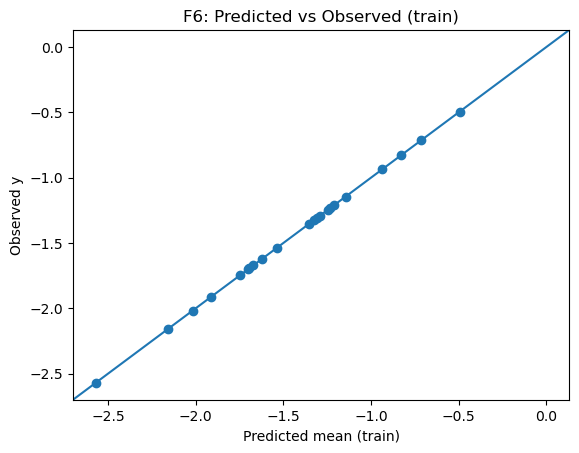

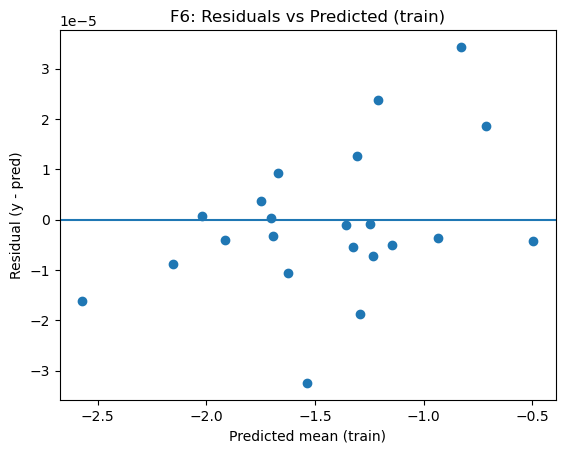

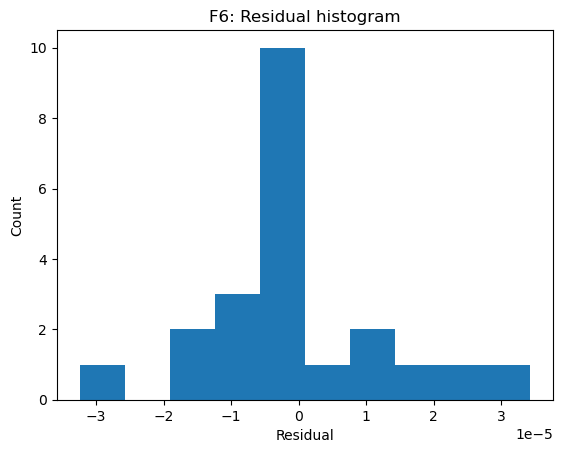


Nearest distance from x_next to existing X: 0.2625310441767445


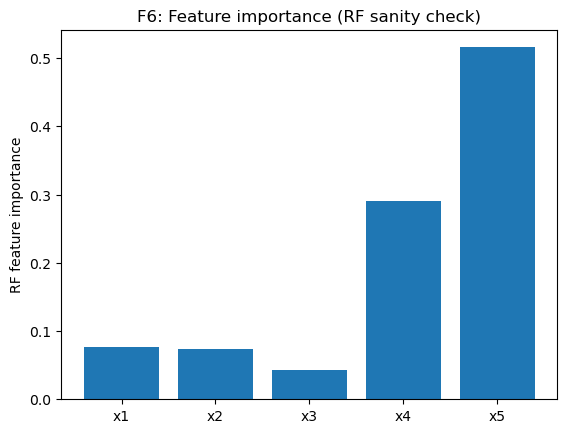


RF importances: {'x1': 0.07717052499299931, 'x2': 0.07389338839180414, 'x3': 0.04236795173378328, 'x4': 0.2908633792522808, 'x5': 0.5157047556291325}


In [10]:
# =========================
# 4) DIAGNOSTICS
# =========================
# 4.1 In-sample predicted mean vs observed
mu_train_n, std_train_n = gp.predict(Xn, return_std=True)
mu_train = scaler_y.inverse_transform(mu_train_n.reshape(-1, 1)).ravel()
std_train = std_train_n * scaler_y.scale_[0]

resid = y - mu_train

plt.figure()
plt.scatter(mu_train, y)
plt.xlabel("Predicted mean (train)")
plt.ylabel("Observed y")
plt.title("F6: Predicted vs Observed (train)")
plt.axline((0, 0), slope=1)
plt.show()

plt.figure()
plt.scatter(mu_train, resid)
plt.xlabel("Predicted mean (train)")
plt.ylabel("Residual (y - pred)")
plt.title("F6: Residuals vs Predicted (train)")
plt.axhline(0)
plt.show()

plt.figure()
plt.hist(resid, bins=10)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("F6: Residual histogram")
plt.show()

# 4.2 Check if search is stuck: distance of x_next to nearest observed point
nearest_dist = float(np.sqrt(np.min(((x_next[None, :] - X) ** 2).sum(axis=1))))
print("\nNearest distance from x_next to existing X:", nearest_dist)

# 4.3 Quick RF feature importance sanity check (nonlinear importance)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_SEED,
    min_samples_leaf=2
)
rf.fit(X, y)
importances = rf.feature_importances_

plt.figure()
plt.bar([f"x{i+1}" for i in range(DIM)], importances)
plt.ylabel("RF feature importance")
plt.title("F6: Feature importance (RF sanity check)")
plt.show()

print("\nRF importances:", {f"x{i+1}": float(importances[i]) for i in range(DIM)})

In [11]:
# =========================
# 5) OUTPUT: ONE ROW TO SUBMIT
# =========================
# Also report GP prediction at x_next (in original y units)
mu_next_n, std_next_n = gp.predict(scaler_X.transform(x_next.reshape(1, -1)), return_std=True)
mu_next = float(scaler_y.inverse_transform(mu_next_n.reshape(-1, 1))[0, 0])
std_next = float(std_next_n[0] * scaler_y.scale_[0])

x_submit = x_next.copy()

print("\n=== RECOMMENDED NEXT X (submit this 1 row) ===")
print(x_submit)
print("Rounded (6 dp):", np.round(x_submit, 6))
print("GP predicted y at x_submit (mean ± std):", mu_next, "±", std_next)


=== RECOMMENDED NEXT X (submit this 1 row) ===
[0.47348199 0.22209129 0.51421834 0.9073413  0.10469833]
Rounded (6 dp): [0.473482 0.222091 0.514218 0.907341 0.104698]
GP predicted y at x_submit (mean ± std): -0.3111130645231879 ± 0.10061759422035048
